In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import xarray as xr
import pyart
from netCDF4 import Dataset
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# from metpy.plots import USCOUNTIES
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")
import glob
import xarray as xr
import sys
sys.path.append('/home/robbyfrost/Analysis/TurbTor_Lidar/')
from lidar_functions import *

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=15)
rc('figure', facecolor='white')


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
jt = 10
dlid = "/data/arrcwx/robbyfrost/halo/20250425/cfrada/"
lfiles = sorted(glob.glob(f"{dlid}*"))
ds = xr.open_dataset(lfiles[jt])

In [3]:
vr = ds.vr.values
az = ds.azimuth.values
r = ds.range.values*1e3
vort = ((vr[2:,:]-vr[:-2,:]) / ((np.deg2rad(az[2:])-np.deg2rad(az[:-2]))[:,None])) / (r[None,:])
x, y = dis_angle_to_2Dxy(r, north0_to_arctheta(az))

tsstr = ds.attrs['time_coverage_start'][:10] + " " + ds.attrs['time_coverage_start'][11:19]
tsdt = datetime.strptime(tsstr, '%Y-%m-%d %H:%M:%S')
testr = ds.attrs['time_coverage_end'][:10] + " " + ds.attrs['time_coverage_end'][11:19]
tedt = datetime.strptime(testr, '%Y-%m-%d %H:%M:%S')

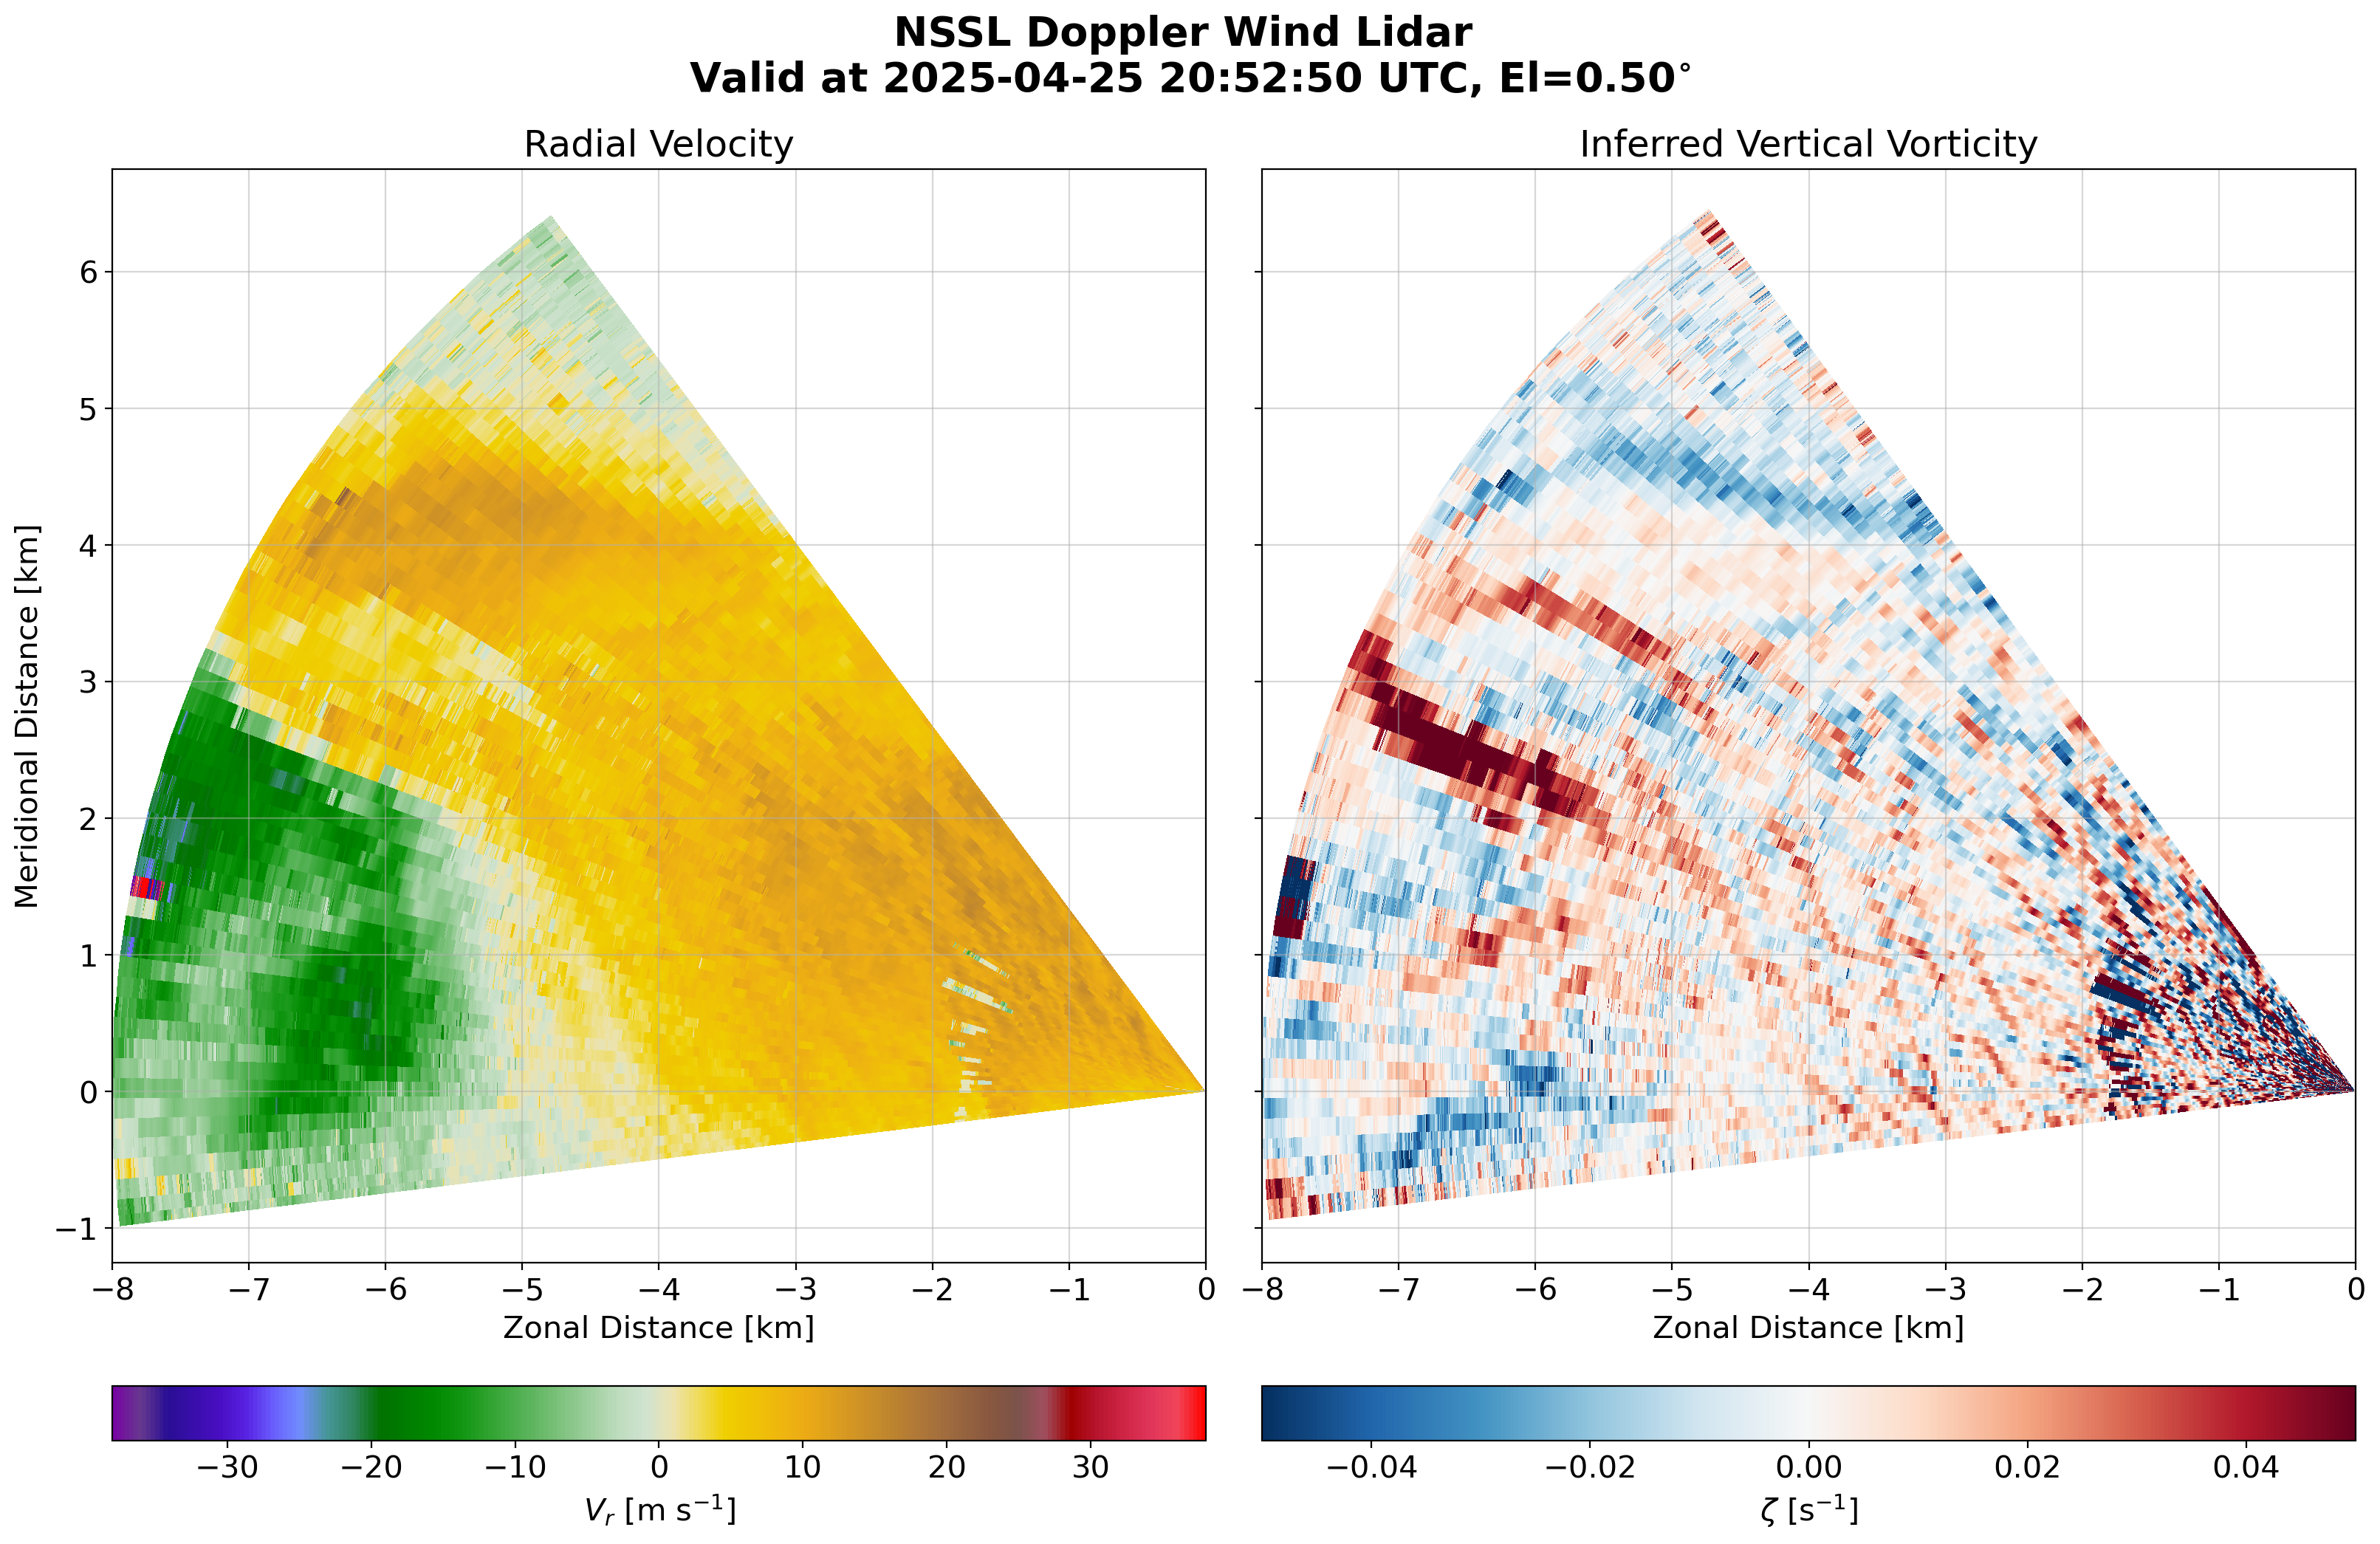

In [4]:
# make figure
fig, axs = plt.subplots(figsize=(16,10.3),
                        ncols=2,
                        sharey=True,
                        constrained_layout=True,
                        dpi=200)
# time
tstr = ds.attrs['time_coverage_start'][:-13]
# elevation
elplt = np.nanmean(ds.elevation.values)
# fig title
fig.suptitle(f"NSSL Doppler Wind Lidar \nValid at {tsdt} UTC, El={elplt:.2f}$\\bf{{^{{\\circ}}}}$", 
                fontsize=20, fontweight='bold')

# radial velocity
ax = axs[0]
ax.set_title("Radial Velocity")
pcm = ax.pcolormesh(x.T/1e3, 
                    y.T/1e3, 
                    vr,
                    cmap='Carbone42',
                    vmin=-38, 
                    vmax=38)
cbar = plt.colorbar(pcm, ax=ax, orientation="horizontal", label="$V_r$ [m s$^{-1}$]", pad=0.03)
ax.set_ylabel("Meridional Distance [km]")
# zeta
ax = axs[1]
ax.set_title("Inferred Vertical Vorticity")
pcm = ax.pcolormesh(x.T[1:-1,:]/1e3, 
                    y.T[1:-1,:]/1e3, 
                    vort,
                    cmap='RdBu_r',
                    vmin=-0.05, 
                    vmax=0.05)
cbar = plt.colorbar(pcm, ax=ax, orientation="horizontal", label="$\\zeta$ [s$^{-1}$]", pad=0.03)

for ax in axs:
    ax.set_aspect('equal')
    ax.grid(alpha=0.5)
    ax.set_xlabel("Zonal Distance [km]")
    ax.set_xlim(-8,0)
    ax.set_ylim(-1.25,6.75)

plt.show()
plt.close(fig)

In [5]:
# dlid = "/Users/robbyfrost/Documents/MS_Project/data/20250425/dltruckdlcsmDL1.b1.20250425_reproc.cdf"
# f = Dataset(dlid)

# bt = float(f.variables['base_time'][:].data)
# to0 = f.variables['time_offset'][:][0]
# hour = f.variables['hour'][:][-1]
# btdt = datetime(1970,1,1,0,0,0) + timedelta(seconds=bt) + timedelta(hours=hour)
# btdt = btdt.replace(microsecond=0)